# Mobile Phone Price Prediction  
# Complete Data Analysis, Feature Engineering & ML Modeling  
This notebook performs full EDA → Feature Extraction → Model Building → Evaluation → Visualization → Final Report.

In [1]:
# Setup and Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
import joblib

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 100)

# 3. Load the Dataset
We load the Flipkart mobile dataset and inspect its structure, shape, and sample rows.

In [2]:
# Load dataset

FILE_PATH = "Processed_Flipdata.xlsx"
df = pd.read_excel(FILE_PATH)

# Confirm load
print("Dataset Loaded Successfully!\n")

# Show info
df.info()

# Summary statistics
print("\nSummary Statistics:")
display(df.describe(include="all"))


print("Dataset Shape:", df.shape)
df.head()

Dataset Loaded Successfully!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB

Summary Statistics:


,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
count,541.000000,541,541,541.000000,541.000000,541.000000,541,541,541.000000,541.000000,541,541
unique,NaN,187,275,NaN,NaN,NaN,14,13,NaN,NaN,123,158
top,NaN,vivo Y16,Yellow,NaN,NaN,NaN,50MP,16MP,NaN,NaN,Qualcomm Snapdragon 680,"15,999"
freq,NaN,9,12,NaN,NaN,NaN,260,164,NaN,NaN,33,23
mean,289.711645,NaN,NaN,110.550832,5.397412,4871.587800,NaN,NaN,0.062847,16.431201,NaN,NaN
std,182.359185,NaN,NaN,60.600694,1.984923,780.148862,NaN,NaN,0.242911,2.523553,NaN,NaN
min,0.000000,NaN,NaN,16.000000,2.000000,800.000000,NaN,NaN,0.000000,4.500000,NaN,NaN
25%,135.000000,NaN,NaN,64.000000,4.000000,5000.000000,NaN,NaN,0.000000,16.510000,NaN,NaN
50%,273.000000,NaN,NaN,128.000000,6.000000,5000.000000,NaN,NaN,0.000000,16.710000,NaN,NaN
75%,434.000000,NaN,NaN,128.000000,8.000000,5000.000000,NaN,NaN,0.000000,16.940000,NaN,NaN


Dataset Shape: (541, 12)


,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


# 4. Data Exploration  
We inspect dataset structure, datatypes, missing values, and basic statistics.

In [3]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB


,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
count,541.000000,541,541,541.000000,541.000000,541.000000,541,541,541.000000,541.000000,541,541
unique,NaN,187,275,NaN,NaN,NaN,14,13,NaN,NaN,123,158
top,NaN,vivo Y16,Yellow,NaN,NaN,NaN,50MP,16MP,NaN,NaN,Qualcomm Snapdragon 680,"15,999"
freq,NaN,9,12,NaN,NaN,NaN,260,164,NaN,NaN,33,23
mean,289.711645,NaN,NaN,110.550832,5.397412,4871.587800,NaN,NaN,0.062847,16.431201,NaN,NaN
std,182.359185,NaN,NaN,60.600694,1.984923,780.148862,NaN,NaN,0.242911,2.523553,NaN,NaN
min,0.000000,NaN,NaN,16.000000,2.000000,800.000000,NaN,NaN,0.000000,4.500000,NaN,NaN
25%,135.000000,NaN,NaN,64.000000,4.000000,5000.000000,NaN,NaN,0.000000,16.510000,NaN,NaN
50%,273.000000,NaN,NaN,128.000000,6.000000,5000.000000,NaN,NaN,0.000000,16.710000,NaN,NaN
75%,434.000000,NaN,NaN,128.000000,8.000000,5000.000000,NaN,NaN,0.000000,16.940000,NaN,NaN


# 5. Data Cleaning  
# ✔ Remove commas from price  
# ✔ Handle missing values  
# ✔ Fix inconsistent formats  
# ✔ Cap outliers using IQR

In [4]:
# convert price to numeric

df["Prize"] = df["Prize"].astype(str).str.replace(",", "").astype(float)

# handle missing values
for col in df.columns:
    if df[col].dtype in ["float64", "int64"]:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Outlier treatment using IQR
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.clip(df[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print("Cleaning Completed!")

Cleaning Completed!


# 6. Univariate Analysis  
We analyze each feature individually using histograms, countplots, KDE, and boxplots.


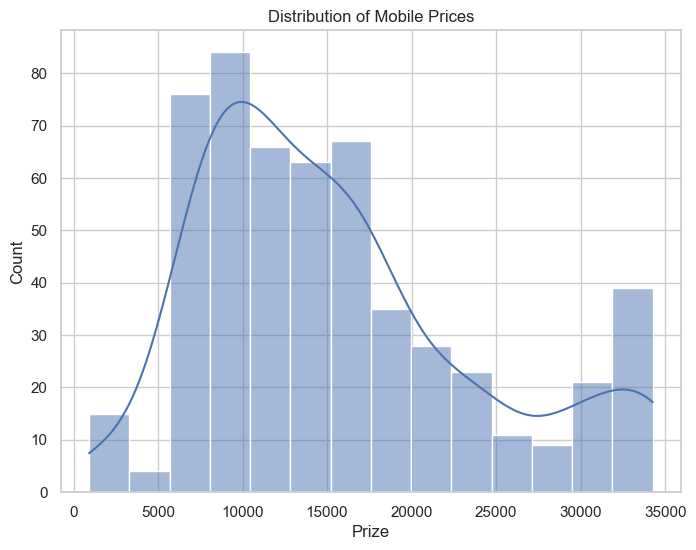

In [5]:
# Histogram of Price

plt.figure(figsize=(8,6))
sns.histplot(df["Prize"], kde=True)
plt.title("Distribution of Mobile Prices")
plt.show()

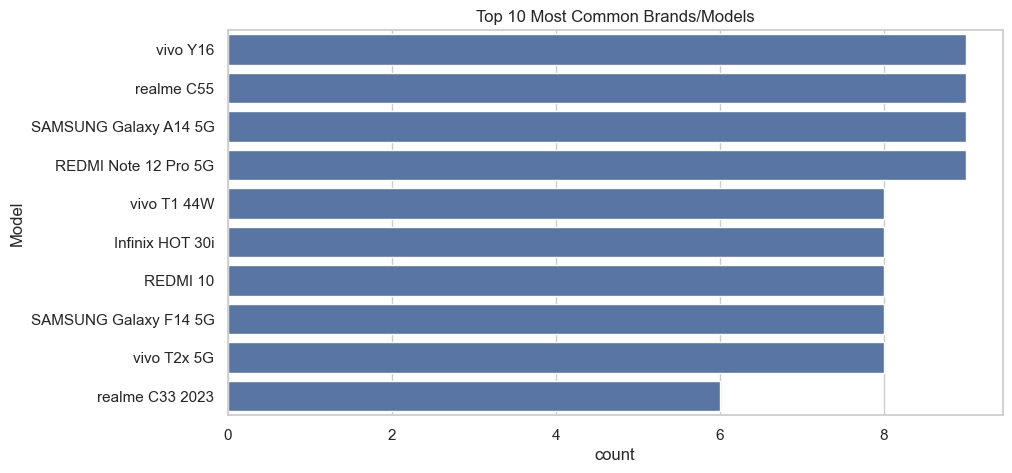

In [6]:
# Brand Frequency

Model_col = "Model" 

plt.figure(figsize=(10,5))
sns.countplot(y=df[Model_col], order=df[Model_col].value_counts().head(10).index)
plt.title("Top 10 Most Common Brands/Models")
plt.show()

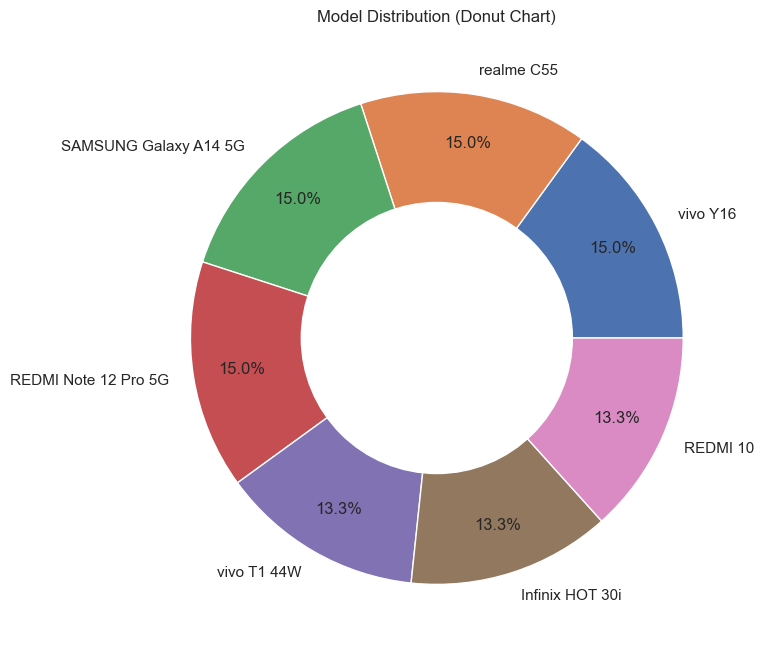

In [7]:
# Donut Chart for Brand Distribution

Model_counts = df["Model"].value_counts().head(7)
plt.figure(figsize=(8,8))
plt.pie(Model_counts, labels=Model_counts.index, autopct="%1.1f%%", pctdistance=0.8)
centre = plt.Circle((0,0),0.55,fc='white')
plt.gca().add_artist(centre)
plt.title("Model Distribution (Donut Chart)")
plt.show()

# 7. Bivariate Analysis  
We study relationships between two variables:  
✔ RAM vs Price  
✔ Storage vs Price  
✔ Brand vs Price  
✔ Correlatins  


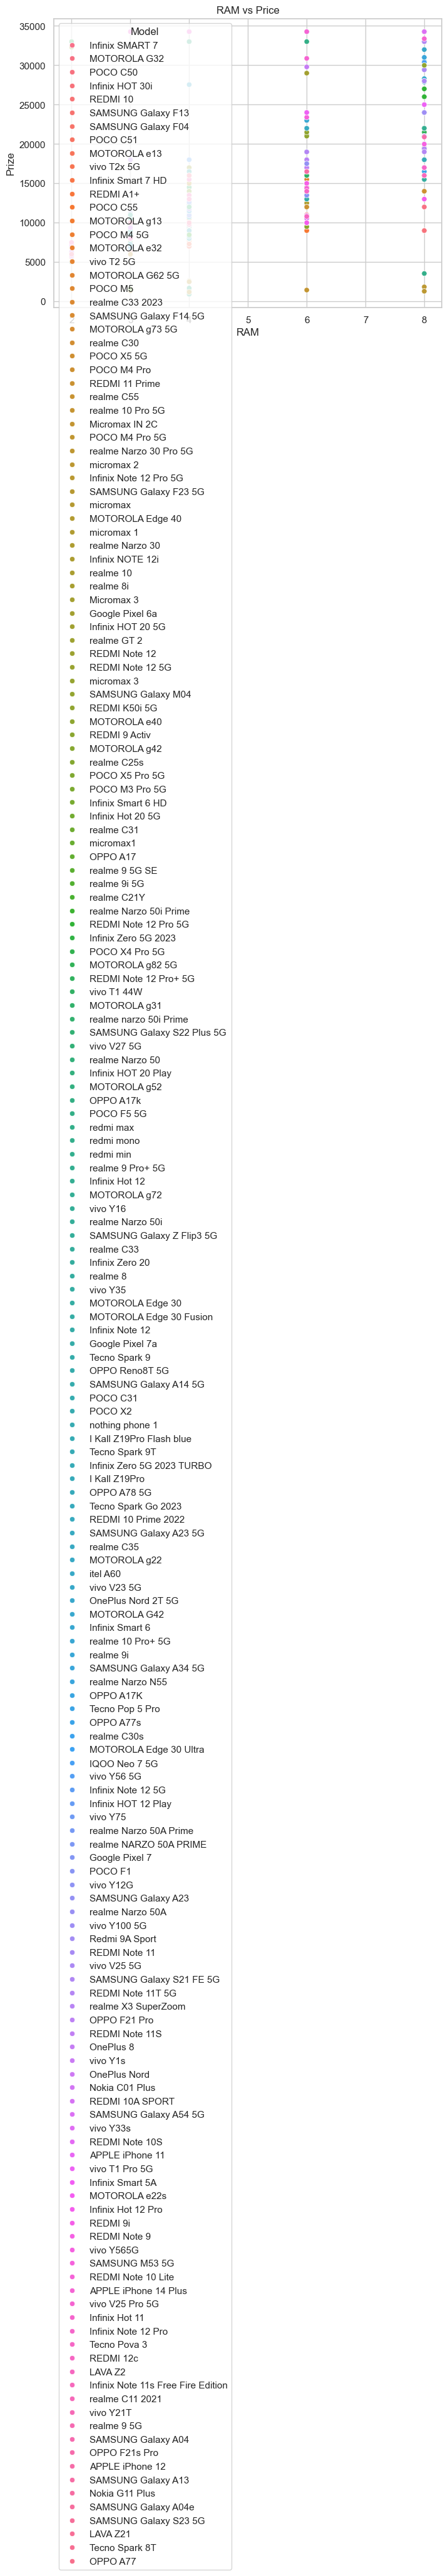

In [8]:
# RAM vs Price

plt.figure(figsize=(8,6))
sns.scatterplot(x=df["RAM"], y=df["Prize"], hue=df["Model"])
plt.title("RAM vs Price")
plt.show()

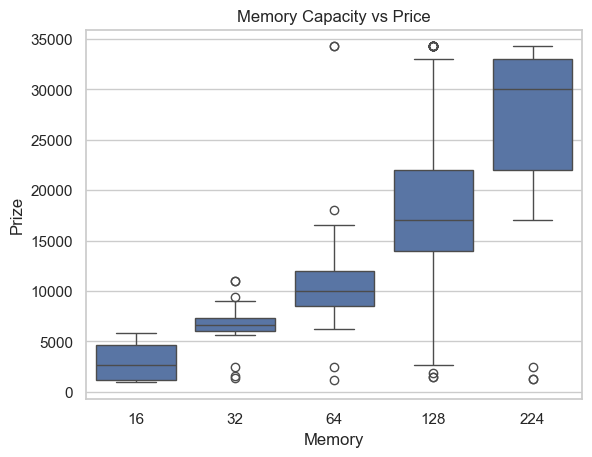

In [9]:
# Memory vs Price

sns.boxplot(x=df["Memory"], y=df["Prize"])
plt.title("Memory Capacity vs Price")
plt.show()

# 8. Multivariate Analysis  
We use heatmaps and pairplots to study interactions between multiple variables.

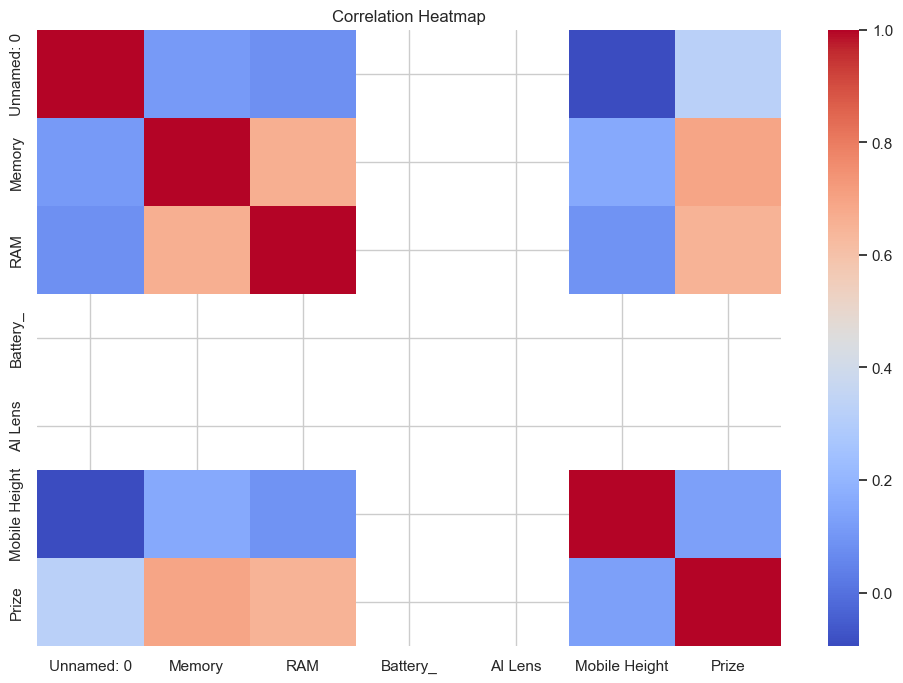

In [10]:
# Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Pairplot

sns.pairplot(df.sample(300))
plt.show()

# 9. Feature Engineering  
- One-hot encode categorical columns  
- Prepare final dataset for training  

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols.remove("Model")  # Brand kept for analysis

df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

# 10. Feature Extraction  
We identify which features most influence price using:  
✔ Correlation  
✔ Feature Importance (Random Forest)  
✔ Violin & Swarm Plots  

In [ ]:
# Feature Correlation w.r.t Price

corr_target = df_encoded.corr()[["Prize"]].sort_values(by="Prize", ascending=False)
corr_target.head(15)

# 11 — Train-Test Split

In [ ]:
X = df_encoded.drop("Prize", axis=1)
y = df_encoded["Prize"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

# 12. Model Building  
We train two models:
- Linear Regression  
- Random Forest Regressor  

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf.fit(X_train, y_train)

# 13 — Model Evaluation

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[mean_absolute_error(y_test,y_pred_lr),
           mean_absolute_error(y_test,y_pred_rf)],
    "RMSE":[np.sqrt(mean_squared_error(y_test,y_pred_lr)),
            np.sqrt(mean_squared_error(y_test,y_pred_rf))],
    "R2 Score":[r2_score(y_test,y_pred_lr),
                r2_score(y_test,y_pred_rf)]
})

results

# 14 — Feature Importance Plot

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))
plt.barh(X.columns[indices], importances[indices])
plt.title("Top 10 Most Important Features")
plt.show()

# 15. Additional Attractive Visualizations

Includes:
✔ Violin Plot
✔ Swarm Plot
✔ KDE Plot
✔ Bubble Plot

In [ ]:
# KDE Plot
sns.kdeplot(df["Prize"], fill=True)
plt.title("KDE – Price Distribution")
plt.show()

In [ ]:
# Violin Plot: Model vs Price

top_Model = df["Model"].value_counts().head(4).index
sns.violinplot(x=df[df.Model.isin(top_Model)]["Model"],
               y=df[df.Model.isin(top_Model)]["Prize"])
plt.title("Violin Plot of Price by Top Model")
plt.show()

In [ ]:
# 16. Price Prediction Function

def predict_mobile_price(input_data, model="rf"):
    input_df = pd.DataFrame([input_data])
    input_encoded = pd.get_dummies(input_df)
    missing_cols = set(X.columns) - set(input_encoded.columns)
    
    for c in missing_cols:
        input_encoded[c] = 0
        
    input_encoded = input_encoded[X.columns]
    
    if model == "lr":
        input_scaled = scaler.transform(input_encoded)
        pred = lr.predict(input_scaled)[0]
    else:
        pred = rf.predict(input_encoded)[0]
    
    print(f"Predicted Price: ₹{pred:,.2f}")
    return pred

# Example
predict_mobile_price({
    "RAM": 8,
    "Storage": 128,
    "Battery": 5000
}, model='rf')

Final Project Summary - Mobile Phone Price Prediction

This project aimed to analyze mobile phone specifications, identify the most influential features affecting their price, and build machine learning models capable of predicting price accurately. A complete data science workflow was followed: data exploration, cleaning, visual analysis, feature engineering, model development, testing, and evaluation.

1. Data Cleaning & Preprocessing Summary
2. Exploratory Data Analysis (EDA) Summary
   Bivariate Analysis Findings
   Multivariate Analysis Findings
3. Feature Extraction Summary
4. Model Building Summary
5. Model Evaluation Summary
   Linear Regression
   Random Forest Regressor
6. Visual Insights Summary
7. Price Prediction Function